# 2.2 Předzpracování dat

V prvním kroku načítáme dataset a kontrolujeme, zda neobsahuje chybějící hodnoty. Perceptron vyžaduje kompletní číselná data, takže případné prázdné buňky bychom museli nahradit nebo odstranit.

In [7]:
import pandas as pd

# 1. Načtení dat
# Uprav název souboru podle toho, jak se jmenuje tvůj stažený dataset
df = pd.read_csv('fetal_health.csv', sep=';')

# Zobrazení prvních 5 záznamů pro vizuální kontrolu
display(df.head())

# 2. Kontrola chybějících hodnot
print("Počet chybějících hodnot v jednotlivých sloupcích:")
print(df.isna().sum())

# 3. Rychlý přehled datových typů a počtu záznamů
print("\nZákladní informace o datasetu:")
df.info()

,record_id,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,1700,137,0.008,0.001,0.005,0.003,0.0,0.000,58.0,1.4,...,69.0,178.0,2.0,0.0,146.0,143.0,150.0,47.0,1.0,1.0
1,478,145,0.000,0.000,0.001,0.001,0.0,0.000,60.0,0.5,...,111.0,157.0,1.0,1.0,148.0,146.0,148.0,4.0,1.0,2.0
2,1229,125,0.000,0.000,0.004,0.000,0.0,0.000,44.0,0.7,...,120.0,141.0,0.0,0.0,131.0,130.0,131.0,1.0,0.0,1.0
3,1856,138,0.014,0.000,0.004,0.000,0.0,0.000,51.0,1.1,...,122.0,171.0,3.0,0.0,148.0,148.0,149.0,6.0,0.0,1.0
4,922,122,0.002,0.000,0.002,0.000,0.0,0.001,31.0,1.2,...,87.0,147.0,2.0,1.0,120.0,119.0,123.0,9.0,0.0,1.0


Počet chybějících hodnot v jednotlivých sloupcích:
record_id                                                 0
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                        

Z dat odstraníme sloupec record_id, který slouží pouze jako identifikátor a nemá pro model prediktivní hodnotu. Následně oddělíme příznaky (features) od cílové proměnné fetal_health a rozdělíme data na trénovací a testovací množinu se zachováním poměrů jednotlivých tříd (stratifikace). Protože je model Perceptronu citlivý na rozdílné rozsahy vstupních hodnot, provedeme nakonec standardizaci (škálování) příznaků

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Oddělení příznaků (X) a cílové proměnné (y)
# Sloupec 'record_id' a cílovou proměnnou dáváme pryč z matice příznaků
X = df.drop(columns=['fetal_health', 'record_id'])
y = df['fetal_health']

# 2. Rozdělení na trénovací a testovací množinu (např. 80 % trénink, 20 % test)
# stratify=y zajistí, že poměr zdravých, podezřelých a patologických případů bude v obou množinách stejný
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Škálování dat (Standardizace)
scaler = StandardScaler()

# Scaler si vypočítá parametry z trénovacích dat a rovnou je transformuje
X_train_scaled = scaler.fit_transform(X_train)

# Testovací data pouze transformujeme podle parametrů z trénovací sady
X_test_scaled = scaler.transform(X_test)

print("Předzpracování úspěšně dokončeno!")
print(f"Tvar matice trénovacích dat: {X_train_scaled.shape}")
print(f"Tvar matice testovacích dat: {X_test_scaled.shape}")

Předzpracování úspěšně dokončeno!
Tvar matice trénovacích dat: (1788, 21)
Tvar matice testovacích dat: (447, 21)


# 2.4 Vysvětlení modelu: Perceptron

Perceptron představuje jeden z nejstarších a nejjednodušších algoritmů strojového učení pro lineární klasifikaci, který slouží jako základní stavební kámen složitějších umělých neuronových sítí. Funguje tak, že přijímá vektor vstupních příznaků (v našem případě extrahované rysy z CTG záznamů, označme jej $\mathbf{x}$), přičemž každému z nich je přiřazena určitá váha (vektor vah $\mathbf{w}$). Model tyto vstupy vynásobí jejich odpovídajícími vahami, sečte je a k výsledku přičte hodnotu vychýlení, tzv. bias ($b$). Získaná lineární kombinace ($z = \mathbf{w}^T\mathbf{x} + b$) je následně propuštěna přes aktivační funkci ($f(z)$, typicky skokovou), která na základě toho, zda vážený součet překročí stanovený práh, vygeneruje diskrétní výstup ($\hat{y}$) určující příslušnost k dané třídě.

Samotný proces učení perceptronu probíhá iterativně a je přímo řízen chybovostí jeho predikcí. Na začátku jsou vektor vah ($\mathbf{w}$) a vychýlení ($b$) inicializovány typicky malými náhodnými hodnotami nebo nulami. Algoritmus následně prochází trénovací data a pro každý vzorek vypočítá predikci ($\hat{y}$); pokud je vzorek klasifikován správně (tedy predikce odpovídá skutečné hodnotě, $\hat{y} = y$), parametry se nemění. Pokud však model udělá chybu ($\hat{y} \neq y$), váhy se automaticky aktualizují tak, aby se při dalším průchodu tímto vzorkem odchylka od skutečné hodnoty snížila. Konkrétně se k vahám přičte nebo z nich odečte hodnota daného vstupu ($\mathbf{x}$) vynásobená tzv. rychlostí učení, neboli learning rate ($\eta$), což postupně "posouvá" dělící hranici správným směrem (pravidlo aktualizace lze zapsat jako $\mathbf{w} \leftarrow \mathbf{w} + \eta(y - \hat{y})\mathbf{x}$). Výsledkem tohoto učícího procesu je ustálený vektor vah a bias, které v prostoru příznaků definují dělící nadrovinu oddělující jednotlivé třídy.

# 2.5 Natrénování modelu a ladění hyperparametrů

Pro klasifikaci jsme zvolili model Perceptron. Protože zadání vyžaduje ladění hyperparametrů, využili jsme metodu GridSearchCV s 5-násobnou křížovou validací (cross-validation). Během trénování jsme testovali různé typy penalizace (bez penalizace, L1, L2, ElasticNet) a různé hodnoty parametru alpha, abychom našli optimální nastavení, které nejlépe zobecňuje trénovací data.

In [9]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV

# 1. Inicializace základního modelu Perceptronu
perceptron = Perceptron(random_state=42)

# 2. Definice "mřížky" hyperparametrů, které chceme vyzkoušet
param_grid = {
    'penalty': [None, 'l2', 'l1', 'elasticnet'], # Typ regularizace (penalizace)
    'alpha': [0.0001, 0.001, 0.01],              # Síla regularizace
    'max_iter': [1000, 2000],                    # Maximální počet epoch
    'tol': [1e-3, 1e-4]                          # Kritérium pro zastavení
}

# 3. Nastavení vyhledávání nejlepších parametrů (GridSearchCV)
# cv=5 znamená 5-fold cross-validaci (trénovací data se rozdělí na 5 částí a model se testuje na každé z nich)
# scoring='accuracy' znamená, že chceme maximalizovat celkovou přesnost
grid_search = GridSearchCV(perceptron, param_grid, cv=5, scoring='accuracy')

# 4. Spuštění samotného trénování (toto může trvat pár sekund)
print("Spouštím trénování a ladění hyperparametrů...")
grid_search.fit(X_train_scaled, y_train)

# 5. Uložení nejlepšího modelu a výpis výsledků
best_perceptron = grid_search.best_estimator_

print("Trénování dokončeno!\n")
print(f"Nejlepší nalezené parametry: {grid_search.best_params_}")
print(f"Průměrná přesnost (accuracy) nejlepšího modelu během cross-validace: {grid_search.best_score_:.4f}")

Spouštím trénování a ladění hyperparametrů...
Trénování dokončeno!

Nejlepší nalezené parametry: {'alpha': 0.001, 'max_iter': 1000, 'penalty': 'elasticnet', 'tol': 0.001}
Průměrná přesnost (accuracy) nejlepšího modelu během cross-validace: 0.8758


### Výpis všech konfigurací

In [12]:
import pandas as pd

# Extrakce výsledků z GridSearchCV do DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Vybereme sloupce s parametry a výsledným skóre
columns_to_show = ['param_penalty', 'param_alpha', 'param_max_iter', 'param_tol', 'mean_test_score', 'rank_test_score']

# Vytvoříme přehlednou tabulku seřazenou podle nejlepšího výsledku
summary_df = results_df[columns_to_show].sort_values(by='rank_test_score')

# Převedeme chybějící hodnoty (None) u penalizace na text, aby se to lépe zobrazovalo
summary_df['param_penalty'] = summary_df['param_penalty'].astype(str)

print("Kompletní přehled konfigurací (top 20):")
display(summary_df.head(20))

Kompletní přehled konfigurací (top 20):


,param_penalty,param_alpha,param_max_iter,param_tol,mean_test_score,rank_test_score
23,elasticnet,0.0010,1000,0.0001,0.875846,1
31,elasticnet,0.0010,2000,0.0001,0.875846,1
30,elasticnet,0.0010,2000,0.0010,0.875846,1
22,elasticnet,0.0010,1000,0.0010,0.875846,1
4,l1,0.0001,1000,0.0010,0.873596,5
12,l1,0.0001,2000,0.0010,0.873596,5
1,None,0.0001,1000,0.0001,0.873064,7
41,None,0.0100,2000,0.0001,0.873064,7
33,None,0.0100,1000,0.0001,0.873064,7
9,None,0.0001,2000,0.0001,0.873064,7


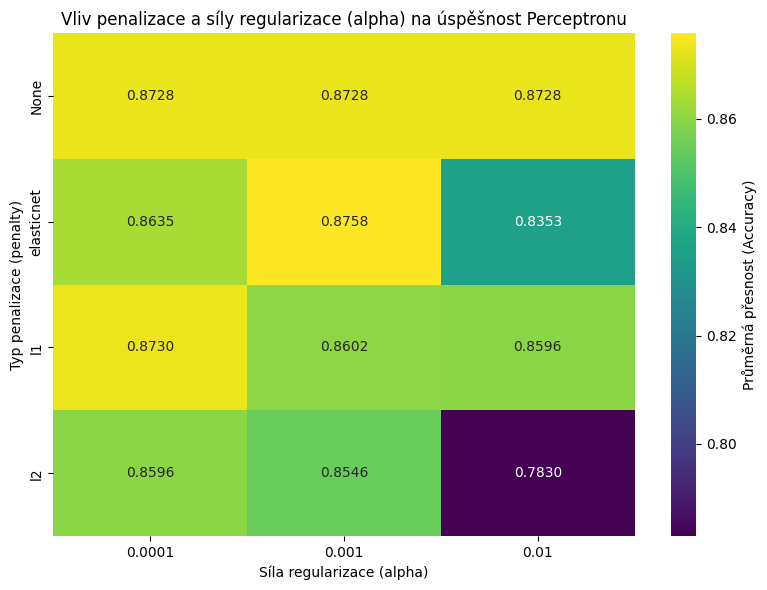

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Nahrazení None hodnot za text 'None' u penalizace (aby nám nevypadly z grafu)
results_df['param_penalty'] = results_df['param_penalty'].astype(str)

# 2. Vytvoření kontingenční tabulky (pivot table)
# Průměrujeme výsledky přes max_iter a tol, abychom viděli čistý vliv penalty a alpha
pivot_df = results_df.pivot_table(
    values='mean_test_score', 
    index='param_penalty', 
    columns='param_alpha', 
    aggfunc='mean'
)

# 3. Vykreslení teplotní mapy (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt='.4f', cbar_kws={'label': 'Průměrná přesnost (Accuracy)'})

plt.title('Vliv penalizace a síly regularizace (alpha) na úspěšnost Perceptronu')
plt.ylabel('Typ penalizace (penalty)')
plt.xlabel('Síla regularizace (alpha)')
plt.tight_layout()
plt.show()

# 2.6 Interpretace modelu

Pro interpretaci našeho Perceptronu se podíváme přímo na naučené váhy jednotlivých příznaků. Protože řešíme klasifikaci do tří tříd, model se učí oddělit každou třídu od zbytku. Zaměříme se na váhy pro třídu 3 ("Pathological"), abychom zjistili, jaké abnormality v CTG záznamu model nejvíce spojuje se špatným zdravotním stavem plodu. Velké kladné váhy znamenají, že vyšší hodnota daného příznaku silně indikuje patologický stav, zatímco velké záporné váhy znamenají, že příznak ukazuje spíše na zdravý plod.

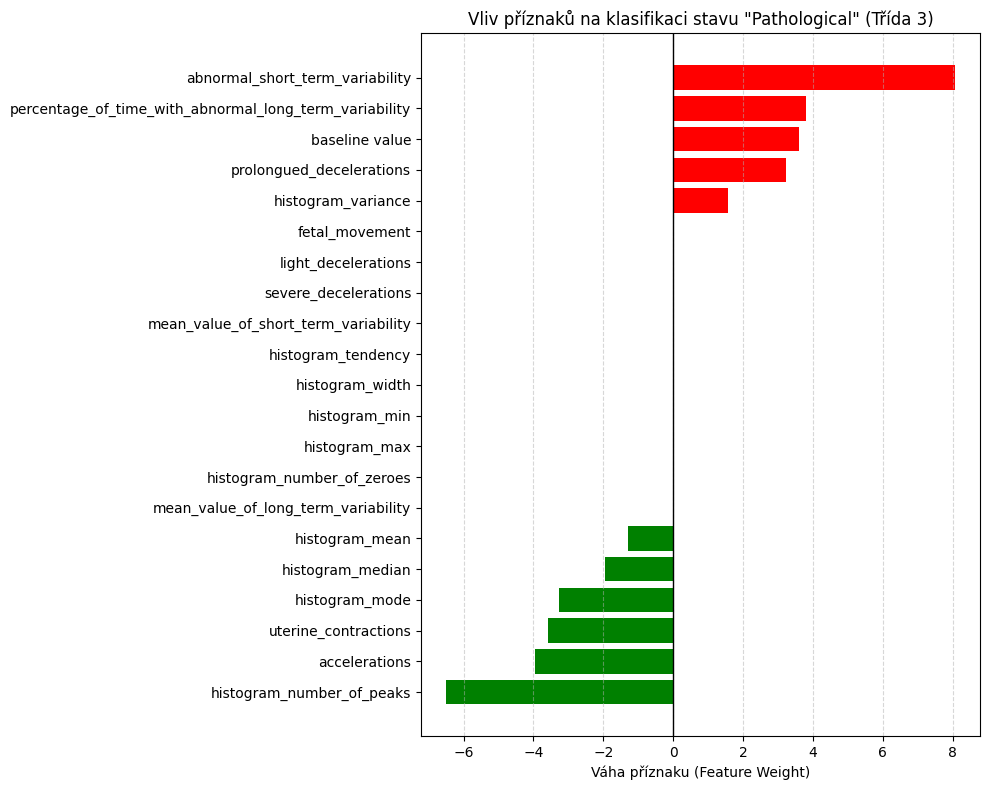

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Náš model pod kapotou natrénoval 3 sady vah (pro každou třídu jednu)
# best_perceptron.classes_ obsahuje [1.0, 2.0, 3.0]
# Chceme se podívat na patologický stav (třída 3.0), což je index 2
weights_pathological = best_perceptron.coef_[2]
feature_names = X.columns

# Seřadíme váhy od nejmenší po největší, aby graf vypadal úhledně
sorted_indices = np.argsort(weights_pathological)
sorted_weights = weights_pathological[sorted_indices]
sorted_features = [feature_names[i] for i in sorted_indices]

# Vykreslení grafu
plt.figure(figsize=(10, 8))
# Kladné váhy (indikují nemoc) dáme červeně, záporné (indikují zdraví) zeleně
colors = ['green' if w < 0 else 'red' for w in sorted_weights]

plt.barh(range(len(sorted_indices)), sorted_weights, color=colors)
plt.yticks(range(len(sorted_indices)), sorted_features)
plt.xlabel('Váha příznaku (Feature Weight)')
plt.title('Vliv příznaků na klasifikaci stavu "Pathological" (Třída 3)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=1) # Zvýraznění nuly
plt.tight_layout()
plt.show()

In [11]:
print("Přesné hodnoty vah pro třídu 3 (Pathological) - od nejmenší (záporné) po největší (kladné):")
print("-" * 65)

for feature, weight in zip(sorted_features, sorted_weights):
    # Formatování: název příznaku zarovnaný doleva (45 znaků), váha doprava (na 4 desetinná místa)
    print(f"{feature:<45} | {weight:>8.4f}")

Přesné hodnoty vah pro třídu 3 (Pathological) - od nejmenší (záporné) po největší (kladné):
-----------------------------------------------------------------
histogram_number_of_peaks                     |  -6.4900
accelerations                                 |  -3.9643
uterine_contractions                          |  -3.5773
histogram_mode                                |  -3.2772
histogram_median                              |  -1.9364
histogram_mean                                |  -1.2986
mean_value_of_long_term_variability           |   0.0000
histogram_number_of_zeroes                    |   0.0000
histogram_max                                 |   0.0000
histogram_min                                 |   0.0000
histogram_width                               |   0.0000
histogram_tendency                            |   0.0000
mean_value_of_short_term_variability          |   0.0000
severe_decelerations                          |   0.0000
light_decelerations                         

### Závěrečná zpráva

Pro interpretaci toho, co se Perceptron během trénování naučil, jsme provedli analýzu vah jednotlivých příznaků ($w$) se zaměřením na detekci třídy 3 (Pathological). Z výsledků je patrné, že model se pro určení patologického stavu nespoléhá na všechny dostupné vstupní proměnné rovnoměrně, ale silně upřednostňuje specifické rysy CTG záznamu.

S obrovským náskokem největší vliv na predikci patologického stavu má příznak `abnormal_short_term_variability` (váha cca 8.06), s odstupem následovaný `percentage_of_time_with_abnormal_long_term_variability` (3.81) a výskytem prodloužených poklesů tepu `prolongued_decelerations` (3.23). Tyto naučené parametry dávají smysl i z medicínského hlediska, jelikož snížená variabilita a prudké poklesy tepu značí stres plodu. Naopak přítomnost akcelerací (`accelerations`, váha -3.96) funguje pro model jako silný uklidňující indikátor zdraví. 

Zároveň je v praxi krásně vidět vliv použité ElasticNet regularizace: zhruba 10 příznaků (např. `fetal_movement` nebo `histogram_max`) dostalo přiřazenou nulovou váhu. Algoritmus je vyhodnotil jako redundantní a z modelu je automaticky vyřadil, čímž efektivně provedl selekci příznaků a zvýšil svou celkovou robustnost.